In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv


c:\Users\Muhammad Hashir\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
c:\Users\Muhammad Hashir\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
load_dotenv()

True

In [4]:
class LLMState(TypedDict):

    title : str 
    outline : str
    blog : str 


In [5]:
model = ChatGroq(model="llama-3.3-70b-versatile")

In [6]:
def generate_outline(state: LLMState) -> LLMState:

    outline_prompt = f"""
    Act as an expert blogger. Generate a detailed outline for a blog post with the title '{state["title"]}'.
    The outline should include:
    - Introduction
    - Main sections with subpoints
    - Conclusion
    Provide only the outline, nothing else.
    """

    outline = model.invoke(outline_prompt)

    state["outline"] = outline.content

    return state



In [7]:
def blog_content(state : LLMState)-> LLMState:

    
    blog_prompt = f"""
    Act as an expert blogger. Using the outline below, write a comprehensive blog post.

    Outline:
    {state['outline']}

    The blog post should be well-structured, engaging, and informative.
    Provide only the blog content, nothing else.
    """

    blog = model.invoke(blog_prompt)

    state["blog"] = blog.content

    return state

In [8]:
graph = StateGraph(LLMState)
graph.add_node("generate_outline", generate_outline)
graph.add_node("blog_content", blog_content)

graph.add_edge(START, "generate_outline")
graph.add_edge("generate_outline", "blog_content")
graph.add_edge("blog_content", END)

workflow = graph.compile()

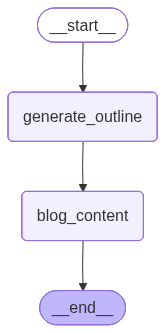

In [9]:
workflow

In [11]:
answer = workflow.invoke({
    "title":"AI in Accounting and CA"
})

In [12]:
answer

{'title': 'AI in Accounting and CA',
 'outline': 'I. Introduction\n    A. Brief overview of AI and its increasing presence in various industries\n    B. Importance of accounting and CA in the business world\n    C. Thesis statement: AI is transforming the accounting and CA profession, increasing efficiency and accuracy\n\nII. Benefits of AI in Accounting and CA\n    A. Automation of routine tasks\n    B. Enhanced accuracy and reduced errors\n    C. Improved financial analysis and forecasting\n    D. Increased compliance with regulations and standards\n    E. Better decision-making with data-driven insights\n\nIII. Applications of AI in Accounting and CA\n    A. Auditing and financial statement analysis\n    B. Tax planning and preparation\n    C. Financial planning and budgeting\n    D. Accounts payable and accounts receivable management\n    E. Financial reporting and compliance\n\nIV. Impact of AI on Accounting and CA Professionals\n    A. Changing role of accountants and CAs\n    B.